In [ ]:
import pandas as pd
import numpy as np
dis_df = pd.read_csv('distribution_center_df.csv(1)')
ev_df = pd.read_csv('event_df.csv(1)')
in_df = pd.read_csv('inventory_item_df.csv(1)')
or_df = pd.read_csv('order_df.csv(1)')
or_it_df = pd.read_csv('order_item_df.csv(1)')
user_df = pd.read_csv('user_df.csv(1)')

In [1]:
import pandas as pd
import numpy as np
ev_df = pd.read_csv('event_df.csv(1)')
ev_df

,event_id,user_id,sequence_number,session_id,occurred_at,browser,traffic_source,uri,event_type
0,2228777,0.0,3,c13fd8d6-3124-4628-903a-9f504408c6a8,2024-01-05 10:31:00 UTC,Chrome,Email,/cancel,cancel
1,1600901,0.0,3,24447ec0-f65f-4217-8749-87684cd1e6e6,2022-02-11 10:54:00 UTC,Chrome,Email,/cancel,cancel
2,1957273,0.0,3,c24ae5ea-5602-46d4-8e3d-3810bea85dcb,2025-01-07 04:20:00 UTC,Chrome,Email,/cancel,cancel
3,1659964,0.0,3,20483386-febf-4778-80aa-c9ffb2247080,2022-10-18 04:22:00 UTC,Chrome,Adwords,/cancel,cancel
4,1710934,0.0,3,abd75ce1-9ffa-432c-b656-aa5ca07f0500,2025-02-17 13:58:00 UTC,Chrome,Email,/cancel,cancel
...,...,...,...,...,...,...,...,...,...
2429727,898472,68767.0,7,83fbfe15-18e2-49ab-afac-338c70b44916,2019-07-18 10:35:42 UTC,Firefox,Email,/purchase,purchase
2429728,1244640,95462.0,13,56e02878-60ca-4655-9788-3450b8ad397b,2025-11-13 19:12:28 UTC,Chrome,Adwords,/purchase,purchase
2429729,1255821,96347.0,5,d7f98019-1a3e-410b-aeae-7cf56ee90d60,2023-06-02 18:03:19 UTC,Firefox,Organic,/purchase,purchase
2429730,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase


In [16]:
ev_df['occurred_at'].value_counts().sort_index(ascending=False)

occurred_at
2026-02-09 00:08:49 UTC           1
2026-02-08 23:57:09.6611 UTC      1
2026-02-08 23:34:35.581805 UTC    1
2026-02-08 23:22:58.801112 UTC    1
2026-02-08 23:13:10.369035 UTC    1
                                 ..
2019-01-02 00:44:00 UTC           1
2019-01-02 00:34:00 UTC           1
2019-01-02 00:26:00 UTC           1
2019-01-02 00:20:00 UTC           1
2019-01-02 00:17:00 UTC           1
Name: count, Length: 2209832, dtype: int64

In [2]:
import pandas as pd
import numpy as np
or_it_df = pd.read_csv('order_item_df.csv(1)')
or_it_df

,order_item_id,order_id,user_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,30624,21284,16892,14235,82570,Complete,2025-06-29 07:34:04 UTC,2025-06-29 13:06:36 UTC,2025-07-01 14:24:36 UTC,0,0.02
1,48427,33577,26659,14235,130515,Complete,2025-09-09 21:49:07 UTC,2025-09-07 19:50:43 UTC,2025-09-10 03:08:43 UTC,0,0.02
2,82129,56839,44907,14235,221524,Complete,2023-09-07 01:59:10 UTC,2023-09-06 06:10:35 UTC,2023-09-07 12:48:35 UTC,0,0.02
3,121090,83627,66403,14235,326621,Processing,2025-01-15 17:51:27 UTC,0,0,0,0.02
4,127935,88339,70173,14235,345011,Processing,2022-02-08 09:23:26 UTC,0,0,0,0.02
...,...,...,...,...,...,...,...,...,...,...,...
181743,113974,78775,62416,24447,307364,Shipped,2025-08-06 15:08:50 UTC,2025-08-08 04:47:41 UTC,0,0,999.00
181744,126924,87654,69629,23546,342301,Shipped,2024-12-26 03:38:37 UTC,2024-12-27 17:40:07 UTC,0,0,999.00
181745,130014,89749,71310,23546,350606,Shipped,2020-12-30 12:06:57 UTC,2021-01-01 08:27:06 UTC,0,0,999.00
181746,133368,92072,73185,23546,359652,Shipped,2024-05-10 08:51:46 UTC,2024-05-13 06:12:19 UTC,0,0,999.00


In [ ]:
# 컬럼명 확인: 합치려는 기준 컬럼의 이름이 서로 다르면 
# left_on='product_id', right_on='id' 처럼 각각 지정해줘야 합니다.

In [ ]:
# users테이블과 order_item테이블을 user_id 기준으로 합치기
merge_df = pd.merge(ev_df, or_it_df, on='user_id', how='inner')

In [35]:
merge_df

,event_id,user_id,sequence_number,session_id,occurred_at,browser,traffic_source,uri,event_type,order_item_id,order_id,product_id,inventory_item_id,status,created_at,shipped_at,delivered_at,returned_at,sale_price
0,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118829,82062,12511,320485,Complete,2024-08-13 13:34:11 UTC,2024-08-12 22:25:26 UTC,2024-08-16 18:31:26 UTC,0,15.900000
1,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118828,82062,10480,320482,Complete,2024-08-11 13:10:07 UTC,2024-08-12 22:25:26 UTC,2024-08-16 18:31:26 UTC,0,62.000000
2,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118827,82061,9927,320479,Returned,2026-01-05 12:50:27 UTC,2026-01-05 17:27:35 UTC,2026-01-10 04:03:35 UTC,2026-01-11 08:21:35 UTC,160.000000
3,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81584,56467,19467,220039,Processing,2023-03-09 02:06:45 UTC,0,0,0,29.410000
4,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81583,56467,27378,220035,Processing,2023-03-08 00:58:44 UTC,0,0,0,34.970001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991245,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177857,122788,23505,479945,Complete,2025-09-25 12:13:38 UTC,2025-09-26 09:20:21 UTC,2025-09-28 10:35:21 UTC,0,23.610001
4991246,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177859,122789,27289,479950,Processing,2024-04-28 00:10:16 UTC,0,0,0,105.000000
4991247,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20048,13920,24956,54050,Shipped,2024-03-11 22:02:52 UTC,2024-03-12 08:37:52 UTC,0,0,23.000000
4991248,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20050,13922,27097,54058,Shipped,2023-04-11 06:43:51 UTC,2023-04-11 20:37:26 UTC,0,0,45.099998


In [64]:
# adwords = 광고유입
# youtube = 광고/소셜
# facebook = 광고/소셜
# organic = 자연유입
# email = 마케팅?섭외
merge_df['traffic_source'].value_counts().sort_values(ascending=False)

traffic_source
Email       2252652
Adwords     1496600
YouTube      500685
Facebook     496683
Organic      244630
Name: count, dtype: int64

In [11]:
merge_df.isna().sum()

id                       0
user_id                  0
sequence_number          0
session_id               0
created_at_x             0
ip_address               0
city                 41973
state                    0
postal_code              0
browser                  0
traffic_source           0
uri                      0
event_type               0
order_item_id            0
order_id                 0
product_id               0
inventory_item_id        0
status                   0
created_at_y             0
shipped_at               0
delivered_at             0
returned_at              0
sale_price               0
dtype: int64

In [12]:
inflow_route = merge_df.groupby('traffic_source')['sale_price'].sum().reset_index()


In [13]:
# 1. 유입 경로별 총 매출 합계
inflow_route = merge_df.groupby('traffic_source')['sale_price'].sum().sort_values(ascending=False)

# 2. 결과 바로 확인
inflow_route

traffic_source
Email       1.339513e+08
Adwords     8.897062e+07
YouTube     2.977825e+07
Facebook    2.929531e+07
Organic     1.454132e+07
Name: sale_price, dtype: float64

<Axes: title={'center': 'Total Revenue by Traffic Source'}, xlabel='traffic_source'>

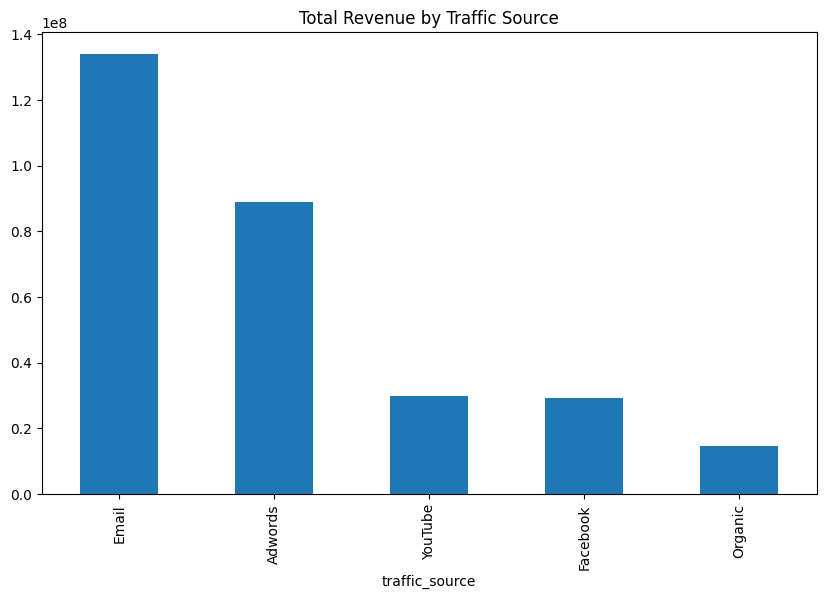

In [ ]:
inflow_route.plot(kind='bar', figsize=(10, 6), title='Total Revenue by Traffic Source')

In [ ]:
#occurred_at 행동이일어난 시간 
#created_at 주문이 접수된 시간
#같은유저아이디끼리 시간이 같다
#occurred_at을통해서 한번에 몇개를 샀는지 볼수있다.count
#한번에 2개의 물건을 장바구니에 담아서
#발송이됐는데 주문이 느리다 날짜가 지금 이상하다!!!
merge_df[['user_id','occurred_at','order_id','created_at','shipped_at']]

,user_id,occurred_at,order_id,created_at,shipped_at
0,65111.0,2026-01-05 12:48:11 UTC,82062,2024-08-13 13:34:11 UTC,2024-08-12 22:25:26 UTC
1,65111.0,2026-01-05 12:48:11 UTC,82062,2024-08-11 13:10:07 UTC,2024-08-12 22:25:26 UTC
2,65111.0,2026-01-05 12:48:11 UTC,82061,2026-01-05 12:50:27 UTC,2026-01-05 17:27:35 UTC
3,44613.0,2023-03-05 02:01:51 UTC,56467,2023-03-09 02:06:45 UTC,0
4,44613.0,2023-03-05 02:01:51 UTC,56467,2023-03-08 00:58:44 UTC,0
...,...,...,...,...,...
4991245,97828.0,2024-04-28 00:09:26 UTC,122788,2025-09-25 12:13:38 UTC,2025-09-26 09:20:21 UTC
4991246,97828.0,2024-04-28 00:09:26 UTC,122789,2024-04-28 00:10:16 UTC,0
4991247,11086.0,2025-11-06 23:55:46 UTC,13920,2024-03-11 22:02:52 UTC,2024-03-12 08:37:52 UTC
4991248,11086.0,2025-11-06 23:55:46 UTC,13922,2023-04-11 06:43:51 UTC,2023-04-11 20:37:26 UTC


In [14]:
merge_df['created_at'].value_counts().sort_index(ascending=False)

created_at
2026-02-09 00:08:49 UTC           57
2026-02-08 23:57:09.6611 UTC      29
2026-02-08 23:34:35.581805 UTC    54
2026-02-08 23:22:58.801112 UTC    35
2026-02-08 23:13:10.369035 UTC    29
                                  ..
2019-01-11 03:42:17 UTC            5
2019-01-06 20:20:22 UTC           67
2019-01-05 19:47:44 UTC           67
2019-01-04 19:03:33 UTC           67
2019-01-04 18:36:52 UTC           67
Name: count, Length: 181624, dtype: int64

In [4]:
#객단가(aov) 총매출액/총 주문건수
total=merge_df['sale_price'].sum()
total_order=merge_df['order_id'].nunique()
aov = total/total_order
print(f'주문건수:{total_order}')
print(f'객단가:{aov:.2f}')

주문건수:125467
객단가:2363.46


In [5]:
# 유입 경로(traffic_source)별로 객단가 차이 확인
source_aov = merge_df.groupby('traffic_source').agg({
    'sale_price': 'sum',
    'order_id': 'nunique'
})
source_aov['AOV'] = source_aov['sale_price'] / source_aov['order_id']

print(source_aov.sort_values('AOV', ascending=False))

                  sale_price  order_id          AOV
traffic_source                                     
Email           1.339513e+08     91799  1459.180100
Adwords         8.897062e+07     72709  1223.653529
YouTube         2.977825e+07     31737   938.281965
Facebook        2.929531e+07     31724   923.442989
Organic         1.454132e+07     17016   854.567420


C:\Users\dlcks\AppData\Local\Temp\ipykernel_7920\1872202629.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='traffic_source', y='AOV', data=plot_data, palette='viridis')


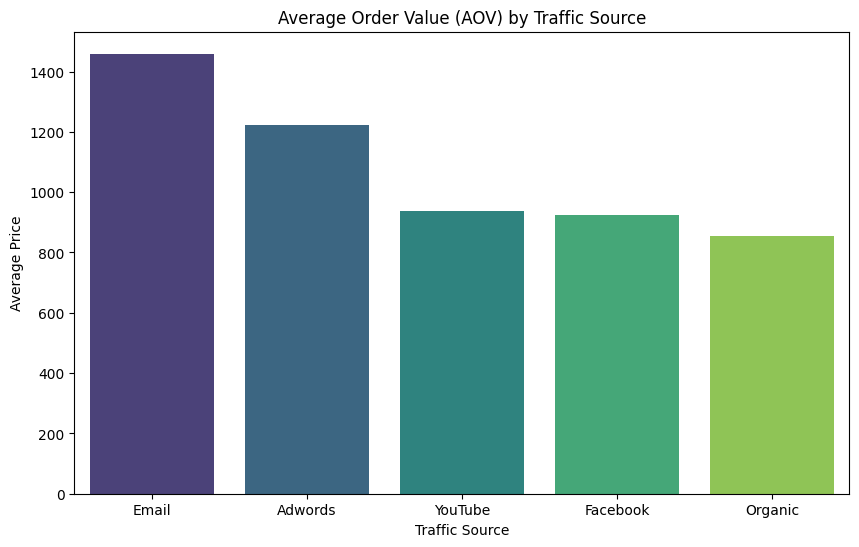

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 데이터 준비 (객단가 순으로 정렬)
plot_data = source_aov.sort_values('AOV', ascending=False).reset_index()

# 그래프 그리기
plt.figure(figsize=(10, 6))
sns.barplot(x='traffic_source', y='AOV', data=plot_data, palette='viridis')

# 꾸미기
plt.title('Average Order Value (AOV) by Traffic Source')
plt.ylabel('Average Price')
plt.xlabel('Traffic Source')
plt.show()

<Axes: xlabel='traffic_source'>

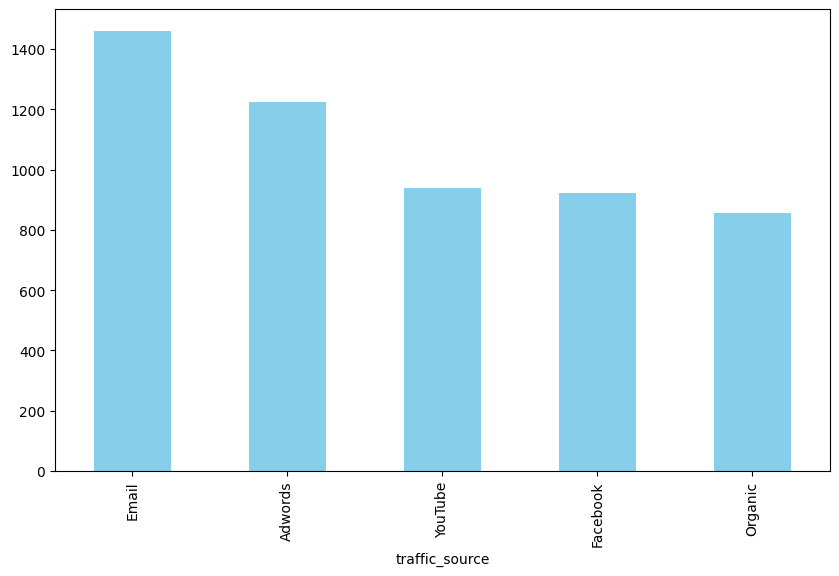

In [7]:
# 여러 컬럼 중 'AOV' 컬럼만 선택해서 그리기
source_aov['AOV'].sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='skyblue')

<Axes: title={'center': 'AOV by Source'}, xlabel='traffic_source'>

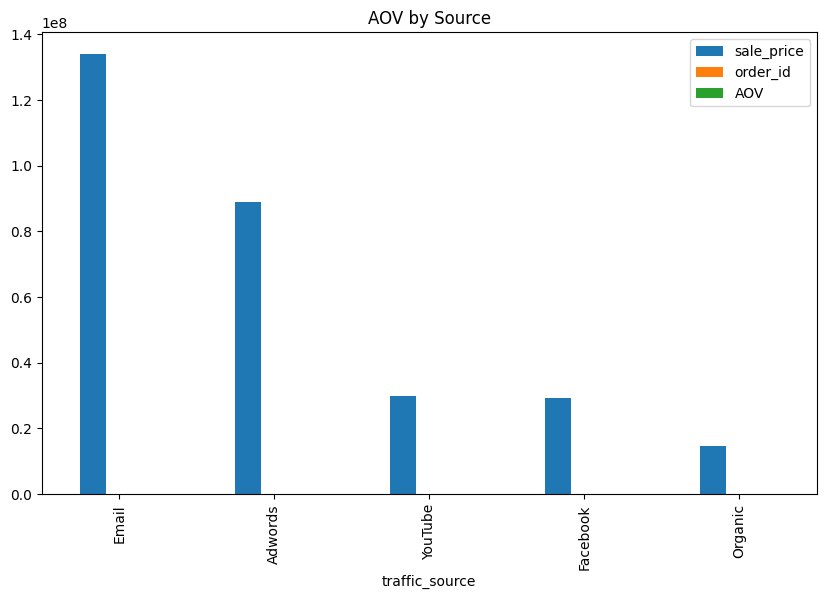

In [62]:
# 정렬을 먼저 하고 plot을 호출하세요!
source_aov.sort_values('AOV', ascending=False).plot(kind='bar', figsize=(10, 6), title='AOV by Source')

<Axes: title={'center': 'AOV'}, xlabel='traffic_source'>

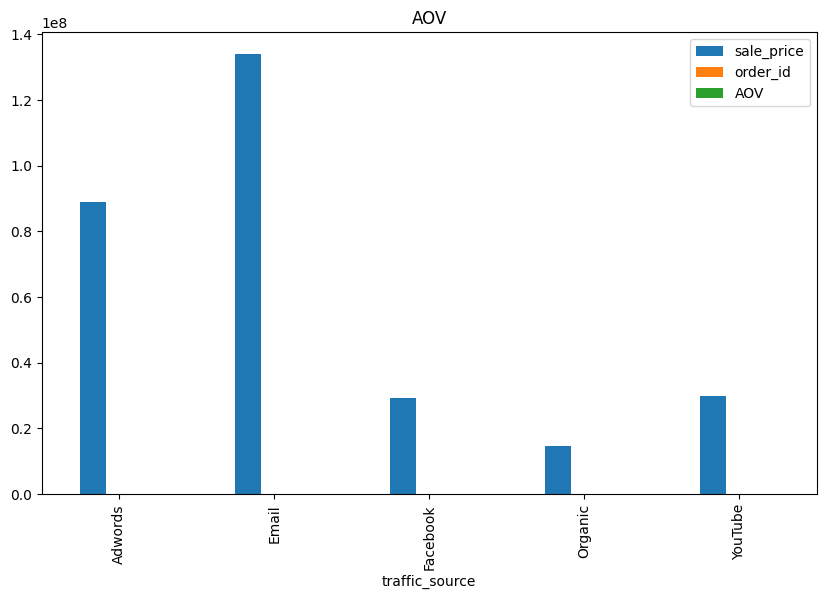

In [60]:
source_aov.plot(kind='bar', figsize=(10, 6), title='AOV')

In [ ]:
#요약 email이가장매출액이높음 사람이 많아서 그럴수도 있음 근데 
# email에유입된사람중 구매력도 높은사람들이 많다
#구매력높은사람들이 각 유입별로 몇명인지 얼마를 썼는지 어떤브랜드샀는지

np.float64(2363.4643196676516)

In [ ]:
# 브랜드 테이블과 합치기 (예시 코드)
# merge_df = pd.merge(merge_df, 브랜드테이블, on='product_id', how='left')

# 그 후 바로 브랜드별 매출 순위 보기!

In [2]:
import pandas as pd
import numpy as np
or_df = pd.read_csv('order_df.csv(1)')
or_df

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
0,48,37,Cancelled,F,2024-08-22 01:33:47 UTC,0,0,0,1
1,76,65,Cancelled,F,2025-08-16 19:33:04 UTC,0,0,0,1
2,92,75,Cancelled,F,2021-09-25 05:34:45 UTC,0,0,0,2
3,119,97,Cancelled,F,2022-06-28 18:03:57 UTC,0,0,0,1
4,124,101,Cancelled,F,2024-06-30 15:21:22 UTC,0,0,0,1
...,...,...,...,...,...,...,...,...,...
125462,125448,99984,Shipped,M,2024-09-24 23:10:38 UTC,0,2024-09-26 11:37:38 UTC,0,2
125463,125458,99989,Shipped,M,2023-01-21 15:20:39 UTC,0,2023-01-22 22:29:39 UTC,0,1
125464,125459,99991,Shipped,M,2021-03-08 15:48:24 UTC,0,2021-03-08 19:52:24 UTC,0,1
125465,125460,99993,Shipped,M,2025-02-23 01:52:51 UTC,0,2025-02-23 15:22:51 UTC,0,1


In [ ]:
or_df[['user_id','occurred_at','order_id','created_at','shipped_at']]

In [5]:
# df라는 데이터프레임에서 shipped_at이 0이 아닌 행만 필터링
result = or_df[or_df['shipped_at'] != '0']
result

,order_id,user_id,status,gender,created_at,returned_at,shipped_at,delivered_at,num_of_item
9138,1,1,Complete,F,2024-09-08 20:32:22 UTC,0,2024-09-10 11:48:22 UTC,2024-09-12 07:00:22 UTC,1
9139,13,13,Complete,F,2025-08-10 10:36:58 UTC,0,2025-08-11 15:40:58 UTC,2025-08-16 10:55:58 UTC,1
9140,15,13,Complete,F,2023-01-01 10:33:10 UTC,0,2023-01-02 03:52:10 UTC,2023-01-04 14:10:10 UTC,1
9141,23,18,Complete,F,2025-02-12 10:52:03 UTC,0,2025-02-14 21:13:03 UTC,2025-02-19 13:38:03 UTC,1
9142,26,21,Complete,F,2022-03-19 13:20:55 UTC,0,2022-03-20 02:07:55 UTC,2022-03-24 07:07:55 UTC,3
...,...,...,...,...,...,...,...,...,...
125462,125448,99984,Shipped,M,2024-09-24 23:10:38 UTC,0,2024-09-26 11:37:38 UTC,0,2
125463,125458,99989,Shipped,M,2023-01-21 15:20:39 UTC,0,2023-01-22 22:29:39 UTC,0,1
125464,125459,99991,Shipped,M,2021-03-08 15:48:24 UTC,0,2021-03-08 19:52:24 UTC,0,1
125465,125460,99993,Shipped,M,2025-02-23 01:52:51 UTC,0,2025-02-23 15:22:51 UTC,0,1


In [7]:
or_df['created_at'].value_counts().sort_index(ascending=False)

created_at
2026-02-05 00:43:12.288273 UTC    1
2026-02-05 00:40:19.420175 UTC    1
2026-02-05 00:39:39.435532 UTC    1
2026-02-05 00:37:30.028482 UTC    1
2026-02-05 00:33:56.445343 UTC    1
                                 ..
2019-01-25 11:17:42 UTC           1
2019-01-23 18:19:34 UTC           1
2019-01-16 19:24:03 UTC           1
2019-01-11 04:21:17 UTC           1
2019-01-03 21:51:42 UTC           1
Name: count, Length: 125413, dtype: int64

In [8]:
import pandas as pd
import numpy as np
in_df = pd.read_csv('inventory_item_df.csv(1)')
in_df
#inventory_item_id

,inventory_item_id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id,pr_category
0,18988,13844,2024-07-18 08:26:30+00:00,2024-09-13 21:58:30+00:00,2.76804,Accessories,ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,Accessories
1,18989,13844,2022-09-30 14:02:00+00:00,0,2.76804,Accessories,ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,Accessories
2,98138,13844,2025-08-04 07:18:50+00:00,2025-09-29 01:29:50+00:00,2.76804,Accessories,ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,Accessories
3,98139,13844,2020-02-23 04:34:00+00:00,0,2.76804,Accessories,ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,Accessories
4,234601,13844,2022-08-03 15:42:36+00:00,2022-08-15 15:20:36+00:00,2.76804,Accessories,ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,Accessories
...,...,...,...,...,...,...,...,...,...,...,...,...,...
490038,359148,25590,2025-07-15 17:05:43+00:00,2025-09-02 08:39:43+00:00,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3,Intimates & Underwear
490039,359149,25590,2022-06-27 11:30:00+00:00,0,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3,Intimates & Underwear
490040,462494,25590,2022-06-07 10:10:50+00:00,2022-06-29 18:23:50+00:00,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3,Intimates & Underwear
490041,462495,25590,2020-12-24 17:25:00+00:00,0,10.39200,Underwear,ck one Men's Micro Slim Fit Boxer,Calvin Klein,24.00,Men,F220707C3AFE39D1779E0A34AF72BB7F,3,Intimates & Underwear


In [9]:
#event_df.csv(1),order_item_df.csv(1),inventory_item_df.csv(1)
inventory_sub=in_df[['product_id','product_brand','product_name','product_category','product_department','pr_category']].drop_duplicates()
mermerg_df=pd.merge(merge_df,inventory_sub,on = 'product_id',how='left')


In [10]:
mermerg_df

,event_id,user_id,sequence_number,session_id,occurred_at,browser,traffic_source,uri,event_type,order_item_id,...,created_at,shipped_at,delivered_at,returned_at,sale_price,product_brand,product_name,product_category,product_department,pr_category
0,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118829,...,2024-08-13 13:34:11 UTC,2024-08-12 22:25:26 UTC,2024-08-16 18:31:26 UTC,0,15.900000,Anna-Kaci,Anna-Kaci S/M Fit Black Pink Polka Dotted Fril...,Intimates,Women,Intimates & Underwear
1,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118828,...,2024-08-11 13:10:07 UTC,2024-08-12 22:25:26 UTC,2024-08-16 18:31:26 UTC,0,62.000000,Le Mystere,Le Mystere Women's Tisha Bra,Intimates,Women,Intimates & Underwear
2,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118827,...,2026-01-05 12:50:27 UTC,2026-01-05 17:27:35 UTC,2026-01-10 04:03:35 UTC,2026-01-11 08:21:35 UTC,160.000000,Natori,Natori Women's Adore Chemise,Sleep & Lounge,Women,Active / Swim / Lounge
3,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81584,...,2023-03-09 02:06:45 UTC,0,0,0,29.410000,Club Room,Club Room Striped Sweater Vest,Sweaters,Men,Tops
4,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81583,...,2023-03-08 00:58:44 UTC,0,0,0,34.970001,Bjorn Borg,Bjorn Borg Men's Cyber Check Pajama Pant,Sleep & Lounge,Men,Active / Swim / Lounge
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991245,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177857,...,2025-09-25 12:13:38 UTC,2025-09-26 09:20:21 UTC,2025-09-28 10:35:21 UTC,0,23.610001,Classroom Uniforms,CLASSROOM Men's Flat Front Short,Shorts,Men,Bottoms
4991246,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177859,...,2024-04-28 00:10:16 UTC,0,0,0,105.000000,Majestic International,Majestic International Men's Parker Hill Lined...,Sleep & Lounge,Men,Active / Swim / Lounge
4991247,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20048,...,2024-03-11 22:02:52 UTC,2024-03-12 08:37:52 UTC,0,0,23.000000,Marcoliani Milano,One Pair Marcoliani Men's ExtraFine Merino Mid...,Socks,Men,Intimates & Underwear
4991248,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20050,...,2023-04-11 06:43:51 UTC,2023-04-11 20:37:26 UTC,0,0,45.099998,Club Room,Club Room Knit Pajama Set Men's,Sleep & Lounge,Men,Active / Swim / Lounge


In [11]:
import pandas as pd
import numpy as np
user_df = pd.read_csv('user_df.csv(1)')

In [24]:
user_df

,user_id,age,gender,state,postal_code,country,latitude,longitude,traffic_source,joined_at,Region
0,3690,53,M,Acre,69980-000,Brasil,-8.065346,-72.870949,Search,2019-09-27 05:21:00 UTC,South America
1,7472,43,M,Acre,69980-000,Brasil,-8.065346,-72.870949,Search,2023-02-03 00:00:00 UTC,South America
2,75113,30,F,Acre,69980-000,Brasil,-8.065346,-72.870949,Search,2019-10-03 17:39:00 UTC,South America
3,95254,30,M,Acre,69980-000,Brasil,-8.065346,-72.870949,Search,2021-04-14 03:30:00 UTC,South America
4,38783,55,M,Acre,69980-000,Brasil,-8.065346,-72.870949,Search,2021-07-01 12:18:00 UTC,South America
...,...,...,...,...,...,...,...,...,...,...,...
99995,21980,47,F,Île-de-France,77120,France,48.789740,3.095796,Search,2021-05-15 06:31:00 UTC,Europe
99996,46496,12,F,Île-de-France,77120,France,48.789740,3.095796,Search,2025-08-16 09:31:00 UTC,Europe
99997,1404,70,M,Île-de-France,77120,France,48.789740,3.095796,Search,2024-05-16 02:31:00 UTC,Europe
99998,50783,24,M,Île-de-France,77160,France,48.589783,3.243343,Search,2025-02-13 05:13:00 UTC,Europe


In [63]:
#event_df.csv(1),order_item_df.csv(1),inventory_item_df.csv(1),user_df.csv(1)
final_df = pd.merge(mermerg_df, user_df[['user_id', 'age', 'gender', 'country']],on='user_id', how='left')
# 3. 2030 세대만 필터링
df_2030 = final_df[(final_df['age'] >= 20) & (final_df['age'] <= 39)]

In [64]:
final_df

,event_id,user_id,sequence_number,session_id,occurred_at,browser,traffic_source,uri,event_type,order_item_id,...,returned_at,sale_price,product_brand,product_name,product_category,product_department,pr_category,age,gender,country
0,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118829,...,0,15.900000,Anna-Kaci,Anna-Kaci S/M Fit Black Pink Polka Dotted Fril...,Intimates,Women,Intimates & Underwear,25,F,Brasil
1,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118828,...,0,62.000000,Le Mystere,Le Mystere Women's Tisha Bra,Intimates,Women,Intimates & Underwear,25,F,Brasil
2,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118827,...,2026-01-11 08:21:35 UTC,160.000000,Natori,Natori Women's Adore Chemise,Sleep & Lounge,Women,Active / Swim / Lounge,25,F,Brasil
3,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81584,...,0,29.410000,Club Room,Club Room Striped Sweater Vest,Sweaters,Men,Tops,60,M,Brasil
4,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81583,...,0,34.970001,Bjorn Borg,Bjorn Borg Men's Cyber Check Pajama Pant,Sleep & Lounge,Men,Active / Swim / Lounge,60,M,Brasil
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991245,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177857,...,0,23.610001,Classroom Uniforms,CLASSROOM Men's Flat Front Short,Shorts,Men,Bottoms,27,M,United Kingdom
4991246,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177859,...,0,105.000000,Majestic International,Majestic International Men's Parker Hill Lined...,Sleep & Lounge,Men,Active / Swim / Lounge,27,M,United Kingdom
4991247,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20048,...,0,23.000000,Marcoliani Milano,One Pair Marcoliani Men's ExtraFine Merino Mid...,Socks,Men,Intimates & Underwear,51,M,United Kingdom
4991248,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20050,...,0,45.099998,Club Room,Club Room Knit Pajama Set Men's,Sleep & Lounge,Men,Active / Swim / Lounge,51,M,United Kingdom


In [65]:
final_df['product_category'].value_counts()

product_category
Intimates                        368212
Jeans                            346349
Tops & Tees                      328764
Fashion Hoodies & Sweatshirts    320874
Shorts                           314060
Swim                             313879
Sleep & Lounge                   312381
Sweaters                         306750
Accessories                      271572
Outerwear & Coats                245276
Active                           245163
Underwear                        208572
Pants                            200442
Socks                            172596
Dresses                          149385
Suits & Sport Coats              140104
Maternity                        138727
Plus                             117205
Socks & Hosiery                  105894
Pants & Capris                    97352
Leggings                          84432
Blazers & Jackets                 83445
Skirts                            56394
Suits                             30097
Jumpsuits & Rompers    

In [66]:
final_df['product_brand'].value_counts()

product_brand
Allegra K            169923
Calvin Klein          94232
Carhartt              70182
Volcom                52961
Hanes                 52854
                      ...  
Fyasko                   10
Colorado Clothing        10
One Teaspoon              5
1veMoon                   5
Sgt Frog                  5
Name: count, Length: 2752, dtype: int64

In [68]:
def age_group(age):
    if age < 20: return '10대'
    elif age < 30: return '20대'
    elif age < 40: return '30대'
    elif age < 50: return '40대'
    elif age < 60: return '50대'
    else: return '60대'
final_df['age_group'] = final_df['age'].apply(age_group)
final_df[['age','age_group']]

,age,age_group
0,25,20대
1,25,20대
2,25,20대
3,60,60대
4,60,60대
...,...,...
4991245,27,20대
4991246,27,20대
4991247,51,50대
4991248,51,50대


In [69]:
final_df['age_group'].value_counts()

age_group
60대    928763
40대    858795
20대    854109
30대    839675
50대    832307
10대    677601
Name: count, dtype: int64

In [70]:
age_brand = final_df.groupby('age_group')['product_category'].value_counts().groupby(level=0).head(3)
age_brand

age_group  product_category             
10대        Intimates                        49234
           Jeans                            46368
           Swim                             45861
20대        Intimates                        66514
           Jeans                            58967
           Fashion Hoodies & Sweatshirts    57043
30대        Intimates                        63500
           Tops & Tees                      57228
           Jeans                            56574
40대        Intimates                        59957
           Jeans                            59882
           Tops & Tees                      58747
50대        Intimates                        62288
           Jeans                            57542
           Fashion Hoodies & Sweatshirts    53890
60대        Jeans                            67016
           Intimates                        66719
           Tops & Tees                      59926
Name: count, dtype: int64

In [71]:
age_brand = final_df.groupby('age_group')['product_brand'].value_counts().groupby(level=0).head(3)
age_brand

age_group  product_brand
10대        Allegra K        23514
           Calvin Klein     12136
           Carhartt         10050
20대        Allegra K        28729
           Calvin Klein     15937
           Carhartt         11480
30대        Allegra K        27180
           Calvin Klein     17261
           Carhartt         12559
40대        Allegra K        28865
           Calvin Klein     16128
           Carhartt         12306
50대        Allegra K        30110
           Calvin Klein     15258
           Carhartt         11412
60대        Allegra K        31525
           Calvin Klein     17512
           Carhartt         12375
Name: count, dtype: int64

c:\Users\dlcks\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


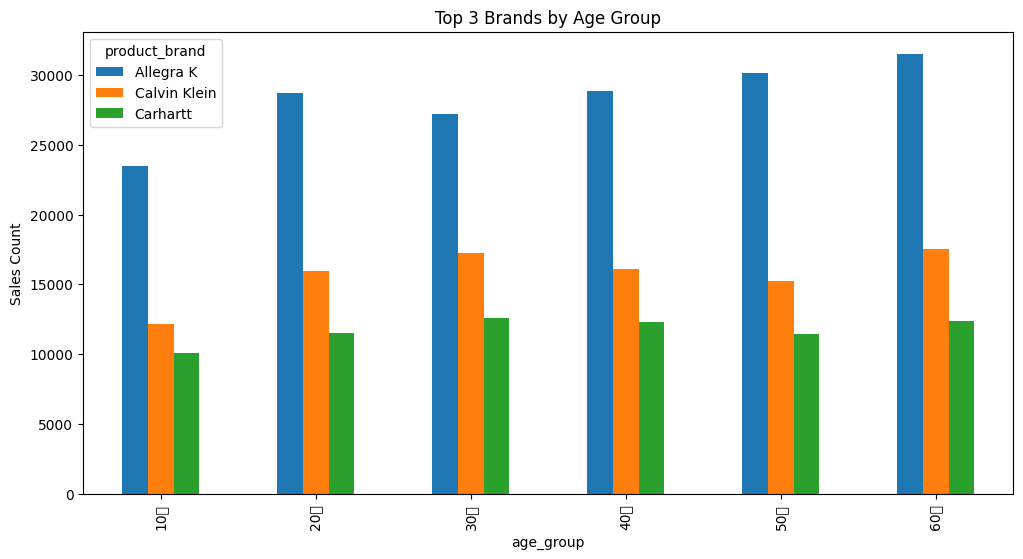

In [72]:
# 다층 구조 데이터를 시각화하기 좋게 표(Pivot) 형태로 바꾼 뒤 그립니다.
age_brand.unstack().plot(kind='bar', figsize=(12, 6), stacked=False)

import matplotlib.pyplot as plt
plt.title("Top 3 Brands by Age Group")
plt.ylabel("Sales Count")
plt.show()

In [73]:
# 연령대와 성별별 구매 건수 집계
age_gender_dist = final_df.groupby(['age_group', 'product_department']).size().unstack(fill_value=0)

print(age_gender_dist)

product_department     Men   Women
age_group                         
10대                 344609  332540
20대                 421490  431861
30대                 422194  416644
40대                 434031  424125
50대                 416754  414609
60대                 464023  463829


In [74]:
# 'age_group'과 'product_department'를 합쳐서 새로운 컬럼 생성
final_df['age_gender'] = final_df['age_group'] + "_" + final_df['product_department']

# 잘 만들어졌는지 상위 5개만 확인
final_df['age_gender'].head()

0    20대_Women
1    20대_Women
2    20대_Women
3      60대_Men
4      60대_Men
Name: age_gender, dtype: object

In [75]:
final_df

,event_id,user_id,sequence_number,session_id,occurred_at,browser,traffic_source,uri,event_type,order_item_id,...,product_brand,product_name,product_category,product_department,pr_category,age,gender,country,age_group,age_gender
0,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118829,...,Anna-Kaci,Anna-Kaci S/M Fit Black Pink Polka Dotted Fril...,Intimates,Women,Intimates & Underwear,25,F,Brasil,20대,20대_Women
1,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118828,...,Le Mystere,Le Mystere Women's Tisha Bra,Intimates,Women,Intimates & Underwear,25,F,Brasil,20대,20대_Women
2,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118827,...,Natori,Natori Women's Adore Chemise,Sleep & Lounge,Women,Active / Swim / Lounge,25,F,Brasil,20대,20대_Women
3,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81584,...,Club Room,Club Room Striped Sweater Vest,Sweaters,Men,Tops,60,M,Brasil,60대,60대_Men
4,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81583,...,Bjorn Borg,Bjorn Borg Men's Cyber Check Pajama Pant,Sleep & Lounge,Men,Active / Swim / Lounge,60,M,Brasil,60대,60대_Men
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991245,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177857,...,Classroom Uniforms,CLASSROOM Men's Flat Front Short,Shorts,Men,Bottoms,27,M,United Kingdom,20대,20대_Men
4991246,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177859,...,Majestic International,Majestic International Men's Parker Hill Lined...,Sleep & Lounge,Men,Active / Swim / Lounge,27,M,United Kingdom,20대,20대_Men
4991247,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20048,...,Marcoliani Milano,One Pair Marcoliani Men's ExtraFine Merino Mid...,Socks,Men,Intimates & Underwear,51,M,United Kingdom,50대,50대_Men
4991248,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20050,...,Club Room,Club Room Knit Pajama Set Men's,Sleep & Lounge,Men,Active / Swim / Lounge,51,M,United Kingdom,50대,50대_Men


In [ ]:
# 주문번호가 여러개인데 시간이 같다
# 리텐션을 구하려고하는데 그냥 order_id가 다른것만하기에는 재구매한게 맞나 의심이 듬
# 진짜 재구매를 보려면 날짜가 다르고 order_id도 달라야 함, 시간빼고 날짜1일을 기준으로 잡겠다
# 실제 주문행위가 서로다른날 2번일어나야 리텐션으로 정의함

In [76]:
final_df[['user_id','order_item_id','occurred_at','order_id','product_id']]

,user_id,order_item_id,occurred_at,order_id,product_id
0,65111.0,118829,2026-01-05 12:48:11 UTC,82062,12511
1,65111.0,118828,2026-01-05 12:48:11 UTC,82062,10480
2,65111.0,118827,2026-01-05 12:48:11 UTC,82061,9927
3,44613.0,81584,2023-03-05 02:01:51 UTC,56467,19467
4,44613.0,81583,2023-03-05 02:01:51 UTC,56467,27378
...,...,...,...,...,...
4991245,97828.0,177857,2024-04-28 00:09:26 UTC,122788,23505
4991246,97828.0,177859,2024-04-28 00:09:26 UTC,122789,27289
4991247,11086.0,20048,2025-11-06 23:55:46 UTC,13920,24956
4991248,11086.0,20050,2025-11-06 23:55:46 UTC,13922,27097


In [33]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4991250 entries, 0 to 4991249
Data columns (total 29 columns):
 #   Column              Dtype  
---  ------              -----  
 0   event_id            int64  
 1   user_id             float64
 2   sequence_number     int64  
 3   session_id          object 
 4   occurred_at         object 
 5   browser             object 
 6   traffic_source      object 
 7   uri                 object 
 8   event_type          object 
 9   order_item_id       int64  
 10  order_id            int64  
 11  product_id          int64  
 12  inventory_item_id   int64  
 13  status              object 
 14  created_at          object 
 15  shipped_at          object 
 16  delivered_at        object 
 17  returned_at         object 
 18  sale_price          float64
 19  product_brand       object 
 20  product_name        object 
 21  product_category    object 
 22  product_department  object 
 23  pr_category         object 
 24  age                 int6

In [77]:
# 날짜 정제
final_df['order_date'] = pd.to_datetime(final_df['occurred_at'],format='mixed')

In [78]:
final_df['only_date'] = final_df['order_date'].dt.date

In [81]:
# 유저별 서로 다른 날짜가 총 몇개인지 리텐션구하는 핵심
drop_df = final_df.drop_duplicates(subset=['user_id', 'order_id', 'occurred_at'])
total_user = drop_df.groupby('user_id').agg({'order_id': 'nunique','only_date': 'nunique'})
retention = total_user[(total_user['order_id'] >= 2) & (total_user['only_date'] >= 2)]
total_count = len(total_user)
reten_count = len(retention)
final_rate = (reten_count / total_count) * 100
print(f"최종 리텐션: {final_rate:.2f}%")


최종 리텐션: 37.34%


In [ ]:
# 1. 완벽하게 똑같은 중복 데이터 제거
final_df_cleaned = final_df.drop_duplicates(subset=['user_id', 'order_id', 'occurred_at'])

# 2. 정제된 데이터로 날짜별 방문 횟수 다시 계산
user_daily_visits = final_df_cleaned.groupby('user_id')['only_date'].nunique()

# 3. 리텐션 계산
two_day = len(user_daily_visits[user_daily_visits >= 2]) # 2일이상 방문한 유저수 구하기
total_count = len(user_daily_visits) # 전체 유저 수 구하기
print(f"전체 유저 수: {total_count}명")
print(f"재방문 유저 수: {two_day}명")
print(f"우리 최종 리텐션: {(two_day / total_count) * 100:.2f}%")

전체 유저 수: 80249명
재방문 유저 수: 44593명
우리 최종 리텐션: 55.57%


In [54]:
# 1. 2030 세대만 필터링 (age_group 컬럼 활용)
df_2030 = final_df[final_df['age_group'].isin(['20대', '30대'])]

# 2. 2030 유저별 방문 일수 계산
user_daily_visits_2030 = df_2030.groupby('user_id')['only_date'].nunique()

# 3. 2030 리텐션 비율 계산
two_day_2030 = len(user_daily_visits_2030[user_daily_visits_2030 >= 2])
total_2030 = len(user_daily_visits_2030)
retention_2030 = (two_day_2030 / total_2030) * 100

print(f"2030 세대 리텐션: {retention_2030:.2f}%")
print(f"전체 평균 대비 차이: {retention_2030 - 55.57:.2f}%p")

2030 세대 리텐션: 55.78%
전체 평균 대비 차이: 0.21%p


In [82]:
drop_df = final_df.drop_duplicates(subset=['user_id', 'order_id', 'occurred_at'])
total_user = drop_df.groupby('user_id').agg({'order_id': 'nunique','only_date': 'nunique'})
retention = total_user[(total_user['order_id'] >= 2) & (total_user['only_date'] >= 2)]

total_count = len(total_user)
reten_count = len(retention)
final_rate = (reten_count / total_count) * 100
print(f"전체 유저 수: {total_count}명")
print(f"재방문 유저 수: {reten_count}명")
print(f"우리 최종 리텐션: {(reten_count / total_count) * 100:.2f}%")

전체 유저 수: 80249명
재방문 유저 수: 29968명
우리 최종 리텐션: 37.34%


In [42]:
final_df

,event_id,user_id,sequence_number,session_id,occurred_at,browser,traffic_source,uri,event_type,order_item_id,...,product_category,product_department,pr_category,age,gender,country,age_group,age_gender,order_date,only_date
0,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118829,...,Intimates,Women,Intimates & Underwear,25,F,Brasil,20대,20대_Women,2026-01-05 12:48:11+00:00,2026-01-05
1,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118828,...,Intimates,Women,Intimates & Underwear,25,F,Brasil,20대,20대_Women,2026-01-05 12:48:11+00:00,2026-01-05
2,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118827,...,Sleep & Lounge,Women,Active / Swim / Lounge,25,F,Brasil,20대,20대_Women,2026-01-05 12:48:11+00:00,2026-01-05
3,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81584,...,Sweaters,Men,Tops,60,M,Brasil,60대,60대_Men,2023-03-05 02:01:51+00:00,2023-03-05
4,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81583,...,Sleep & Lounge,Men,Active / Swim / Lounge,60,M,Brasil,60대,60대_Men,2023-03-05 02:01:51+00:00,2023-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991245,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177857,...,Shorts,Men,Bottoms,27,M,United Kingdom,20대,20대_Men,2024-04-28 00:09:26+00:00,2024-04-28
4991246,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177859,...,Sleep & Lounge,Men,Active / Swim / Lounge,27,M,United Kingdom,20대,20대_Men,2024-04-28 00:09:26+00:00,2024-04-28
4991247,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20048,...,Socks,Men,Intimates & Underwear,51,M,United Kingdom,50대,50대_Men,2025-11-06 23:55:46+00:00,2025-11-06
4991248,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20050,...,Sleep & Lounge,Men,Active / Swim / Lounge,51,M,United Kingdom,50대,50대_Men,2025-11-06 23:55:46+00:00,2025-11-06


In [56]:
final_df['country'].value_counts()

country
China             1708635
United States     1095213
Brasil             723990
South Korea        270730
United Kingdom     234999
France             231373
Germany            209180
Spain              206405
Australia          116651
Japan              115929
Belgium             67049
Poland              10974
Colombia              102
Austria                20
Name: count, dtype: int64

In [ ]:
# 1. 먼저 한국 유저 데이터만 필터링합니다.
df_kor = final_df[final_df['country'] == 'South Korea']

# 2. 한국 유저 데이터에서 중복을 제거합니다.
drop_df_kor = df_kor.drop_duplicates(subset=['user_id', 'order_id', 'occurred_at'])

# 3. 한국 유저별로 주문수(order_id)와 방문날짜수(only_date)를 계산합니다.
total_user_kor = drop_df_kor.groupby('user_id').agg({'order_id': 'nunique','only_date': 'nunique'})

# 4. 엄격한 리텐션 조건 적용 (주문 2개 이상 AND 날짜 2일 이상)
retention_kor = total_user_kor[(total_user_kor['order_id'] >= 2) & (total_user_kor['only_date'] >= 2)]

# 5. 숫자 세기 및 결과 출력
total_count = len(total_user_kor)
reten_count = len(retention_kor)

print(f"🇰🇷 한국 전체 유저 수: {total_count}명")
print(f"🇰🇷 한국 재구매 유저 수: {reten_count}명")
print(f"🇰🇷 한국 최종 리텐션: {(reten_count / total_count) * 100:.2f}%")

🇰🇷 한국 전체 유저 수: 4286명
🇰🇷 한국 재구매 유저 수: 1598명
🇰🇷 한국 최종 리텐션: 37.28%


In [ ]:
# 1. 한국 유저 데이터만 먼저 따로 떼어내기
df_kor = final_df[final_df['country'] == 'South Korea']

# 2. 리텐션 계산 함수 정의
def get_strict_retention(group):
    # 중복 제거 (유저, 주문번호, 시간)
    clean_group = group.drop_duplicates(subset=['user_id', 'order_id', 'occurred_at'])
    
    # 유저별 주문수, 날짜수 집계
    stats = clean_group.groupby('user_id').agg({
        'order_id': 'nunique',
        'only_date': 'nunique'
    })
    
    # 분모: 해당 연령대 전체 구매 유저 수
    total_count = len(stats)
    
    # 분자: 엄격한 조건(주문 2개 & 날짜 2일 이상) 만족 유저 수
    retained_count = len(stats[(stats['order_id'] >= 2) & (stats['only_date'] >= 2)])
    
    # 리텐션 비율 계산
    return (retained_count / total_count) * 100 if total_count > 0 else 0

# 3. 한국인 데이터(df_kor)를 연령대별로 그룹화하여 함수 적용
kor_age_retention = df_kor.groupby('age_group').apply(get_strict_retention)

# 4. 결과 출력
print("🇰🇷 한국 유저 연령대별 리텐션 순위:")
print(kor_age_retention.sort_values(ascending=False))

🇰🇷 한국 유저 연령대별 리텐션 순위:
age_group
40대    39.769452
30대    38.418863
60대    37.545565
10대    36.130137
50대    35.939643
20대    35.782313
dtype: float64


C:\Users\dlcks\AppData\Local\Temp\ipykernel_7920\2309382463.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kor_age_retention = df_kor.groupby('age_group').apply(get_strict_retention)


In [85]:
final_df

,event_id,user_id,sequence_number,session_id,occurred_at,browser,traffic_source,uri,event_type,order_item_id,...,product_category,product_department,pr_category,age,gender,country,age_group,age_gender,order_date,only_date
0,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118829,...,Intimates,Women,Intimates & Underwear,25,F,Brasil,20대,20대_Women,2026-01-05 12:48:11+00:00,2026-01-05
1,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118828,...,Intimates,Women,Intimates & Underwear,25,F,Brasil,20대,20대_Women,2026-01-05 12:48:11+00:00,2026-01-05
2,852082,65111.0,4,8996573f-8b7f-4693-89bf-cd55a094258c,2026-01-05 12:48:11 UTC,Chrome,Email,/cart,cart,118827,...,Sleep & Lounge,Women,Active / Swim / Lounge,25,F,Brasil,20대,20대_Women,2026-01-05 12:48:11+00:00,2026-01-05
3,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81584,...,Sweaters,Men,Tops,60,M,Brasil,60대,60대_Men,2023-03-05 02:01:51+00:00,2023-03-05
4,583424,44613.0,3,892a2ec4-611d-4df8-9757-b0d506431a70,2023-03-05 02:01:51 UTC,Chrome,Email,/cart,cart,81583,...,Sleep & Lounge,Men,Active / Swim / Lounge,60,M,Brasil,60대,60대_Men,2023-03-05 02:01:51+00:00,2023-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991245,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177857,...,Shorts,Men,Bottoms,27,M,United Kingdom,20대,20대_Men,2024-04-28 00:09:26+00:00,2024-04-28
4991246,1275524,97828.0,5,2d17565f-f5e4-49eb-93b1-589ba0eb4b85,2024-04-28 00:09:26 UTC,Firefox,Email,/purchase,purchase,177859,...,Sleep & Lounge,Men,Active / Swim / Lounge,27,M,United Kingdom,20대,20대_Men,2024-04-28 00:09:26+00:00,2024-04-28
4991247,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20048,...,Socks,Men,Intimates & Underwear,51,M,United Kingdom,50대,50대_Men,2025-11-06 23:55:46+00:00,2025-11-06
4991248,142628,11086.0,5,c8632f64-270e-4e53-80aa-31a5d57aa7c7,2025-11-06 23:55:46 UTC,Firefox,Facebook,/purchase,purchase,20050,...,Sleep & Lounge,Men,Active / Swim / Lounge,51,M,United Kingdom,50대,50대_Men,2025-11-06 23:55:46+00:00,2025-11-06


In [ ]:
final_df['country'].value_counts()

In [87]:
final_df[final_df['country'] == 'South Korea']['product_category'].value_counts()

product_category
Jeans                            20210
Tops & Tees                      18786
Shorts                           18402
Intimates                        17974
Sleep & Lounge                   17185
Swim                             16701
Fashion Hoodies & Sweatshirts    16602
Sweaters                         16243
Outerwear & Coats                14497
Accessories                      14039
Active                           13988
Underwear                        12059
Pants                            11629
Socks                            10276
Dresses                           7433
Maternity                         7253
Suits & Sport Coats               6639
Socks & Hosiery                   6088
Plus                              5981
Leggings                          4704
Pants & Capris                    4481
Blazers & Jackets                 4130
Skirts                            2598
Suits                             1317
Jumpsuits & Rompers               1099
Clothing